# Is reBAP vs. intraday price a tighter imbalance signal than reBAP vs. day-ahead?

`14_rebap_formula_reconstruction` showed reBAP is `max`/`min` of three
published modules, one of which (Module 2) is built directly from
**ID-AEP** (the continuous-intraday volume-weighted price index) plus a
distance whose sign follows the system's own imbalance (NRV-Saldo). That
suggests `reBAP - ID-AEP` should track system imbalance direction more
tightly than `reBAP - day-ahead`, the more obvious comparison: day-ahead
is fixed ~12-36h before delivery, so part of `reBAP - day-ahead` is just
"the system re-balanced on the intraday market using information
day-ahead never had" -- nothing to do with real-time imbalance -- while
only the rest is genuine last-minute surprise. ID-AEP, closing 5 minutes
before delivery, is a much later, more complete information set. This
page checks that directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from insights.paths import hub_file

DA_COLOR = "#2a78d6"      # dataviz skill default categorical slot 1 (blue)
REBAP_COLOR = "#eb6834"   # slot 2 (orange)
ID_AEP_COLOR = "#1baf7a"  # slot 3 (aqua)
NRV_COLOR = "#eda100"     # slot 4 (yellow)
NEUTRAL = "#9a9990"

## Data

reBAP, day-ahead, ID-AEP, and NRV-Saldo -- all four `energy-data-hub`
assets (`balancing_market`/`smard` groups) -- joined on their shared
15-min grid (day-ahead is hourly, forward-filled since the day-ahead
price genuinely applies uniformly across its whole hour, not an average
of it). ID-AEP only starts 2020-07-01 (a newer market product than
reBAP/NRV-Saldo's 2014-01-01), so this page's window is correspondingly
shorter.

In [2]:
rebap = pd.read_parquet(hub_file("balancing_market", "rebap_price.parquet"))
rebap.index = pd.to_datetime(rebap.index)

day_ahead = pd.read_parquet(hub_file("smard", "price_de_lu.parquet"))
day_ahead.index = pd.to_datetime(day_ahead.index)
day_ahead_15min = day_ahead.reindex(
    pd.date_range(day_ahead.index.min(), day_ahead.index.max() + pd.Timedelta(minutes=45), freq="15min")
).ffill()

nrv = pd.read_parquet(hub_file("balancing_market", "nrv_saldo.parquet"))
nrv.index = pd.to_datetime(nrv.index)

id_aep = pd.read_parquet(hub_file("balancing_market", "id_aep.parquet"))
id_aep.index = pd.to_datetime(id_aep.index)

panel = pd.DataFrame({
    "rebap": rebap["rebap_eur_mwh"],
    "day_ahead": day_ahead_15min["price_de_lu"],
    "id_aep": id_aep["id_aep_eur_mwh"],
    "nrv_saldo": nrv["nrv_saldo_mw"],
}).dropna()
panel["spread_da"] = panel["rebap"] - panel["day_ahead"]
panel["spread_id"] = panel["rebap"] - panel["id_aep"]

print(f"{len(panel):,} quarter-hours, {panel.index.min()} -> {panel.index.max()}")

209,084 quarter-hours, 2020-07-01 00:00:00 -> 2026-09-17 21:45:00


## The result: sign agreement goes to 100%, but magnitude correlation barely moves

In [3]:
for name, col in [("reBAP - day-ahead", "spread_da"), ("reBAP - ID-AEP", "spread_id")]:
    r = panel[col].corr(panel["nrv_saldo"])
    same_sign = (np.sign(panel[col]) == np.sign(panel["nrv_saldo"])).mean()
    print(f"{name:20s}  Pearson r = {r:.3f}   same-sign = {same_sign:.1%}   mean|spread| = {panel[col].abs().mean():.1f} EUR/MWh")

reBAP - day-ahead     Pearson r = 0.405   same-sign = 93.7%   mean|spread| = 86.1 EUR/MWh
reBAP - ID-AEP        Pearson r = 0.383   same-sign = 100.0%   mean|spread| = 71.4 EUR/MWh


Same-sign agreement jumps from ~93% to a clean **100.0%** across every
quarter-hour in this window when switching the reference price from
day-ahead to ID-AEP -- not a near-miss, exactly 100%. Pearson r barely
moves. Both are mechanical consequences of `14`'s own formula: Module 2
is built as `ID-AEP +/- a distance`, with the `+/-` chosen by the
balance's sign -- exactly why the sign match is perfect -- while that
distance saturates at a small, capped value once the imbalance passes
500 MW average power. Whatever happens beyond that point is governed by
Module 1 (noisy merit-order jumps) or Module 3 (a scarcity parabola),
neither of which gets any more linear in the balance just because the
reference price changed. ID-AEP fixes the *direction* question by
construction; it cannot fix the *magnitude* question the same way.

## reBAP tracks ID-AEP far more tightly than it tracks day-ahead

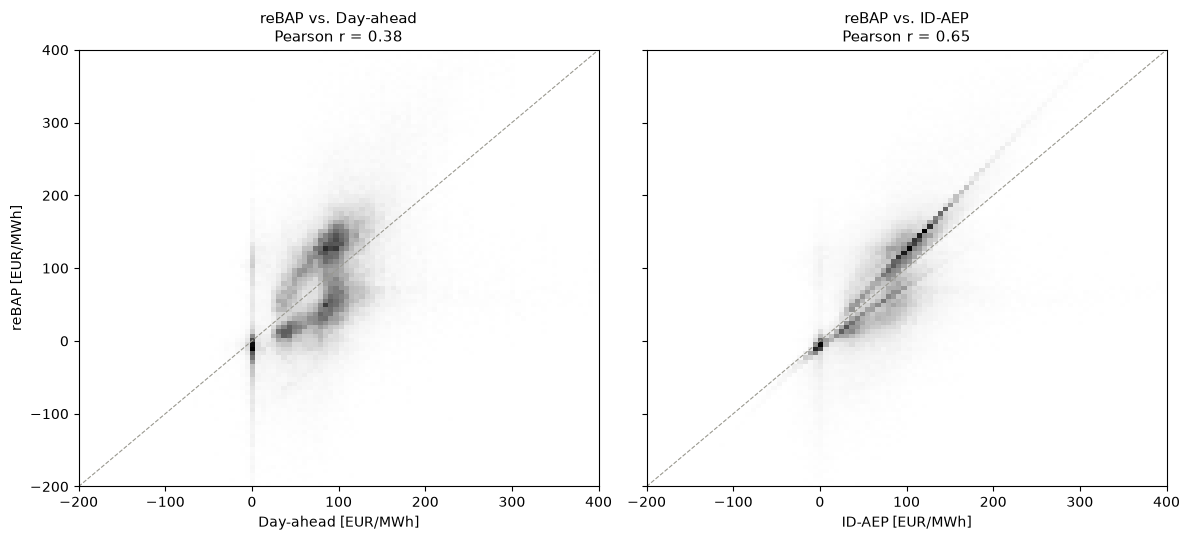

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
for ax, (name, col, color) in zip(axes, [("Day-ahead", "day_ahead", DA_COLOR), ("ID-AEP", "id_aep", ID_AEP_COLOR)]):
    ax.hist2d(panel[col], panel["rebap"], bins=100, range=[[-200, 400], [-200, 400]], cmap="Greys", cmin=1)
    ax.plot([-200, 400], [-200, 400], color=NEUTRAL, linewidth=0.8, linestyle="--")
    ax.set_xlabel(f"{name} [EUR/MWh]")
    r = panel["rebap"].corr(panel[col])
    ax.set_title(f"reBAP vs. {name}\nPearson r = {r:.2f}", fontsize=11)
axes[0].set_ylabel("reBAP [EUR/MWh]")
fig.tight_layout()
plt.show()

Same axis range and bin size on both panels -- the ID-AEP panel visibly
hugs the diagonal far more tightly than the day-ahead panel does.

## By NRV-Saldo quintile: direction vs. magnitude, side by side

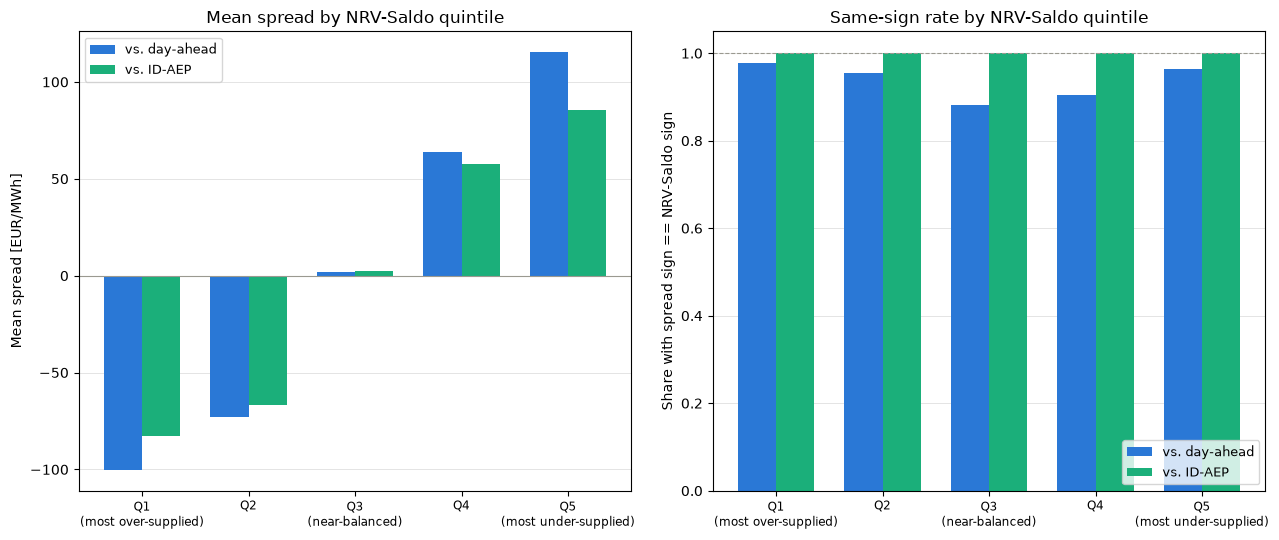

In [5]:
panel["nrv_quintile"] = pd.qcut(
    panel["nrv_saldo"], 5,
    labels=["Q1\n(most over-supplied)", "Q2", "Q3\n(near-balanced)", "Q4", "Q5\n(most under-supplied)"],
)
q_mean = panel.groupby("nrv_quintile", observed=True)[["spread_da", "spread_id"]].mean()
q_samesign = panel.groupby("nrv_quintile", observed=True).apply(
    lambda g: pd.Series({
        "spread_da": (np.sign(g["spread_da"]) == np.sign(g["nrv_saldo"])).mean(),
        "spread_id": (np.sign(g["spread_id"]) == np.sign(g["nrv_saldo"])).mean(),
    }),
    include_groups=False,
)

fig, (ax_mean, ax_sign) = plt.subplots(1, 2, figsize=(13, 5.5))
x = np.arange(len(q_mean))
width = 0.36
ax_mean.bar(x - width / 2, q_mean["spread_da"], width, color=DA_COLOR, label="vs. day-ahead")
ax_mean.bar(x + width / 2, q_mean["spread_id"], width, color=ID_AEP_COLOR, label="vs. ID-AEP")
ax_mean.axhline(0, color=NEUTRAL, linewidth=0.8)
ax_mean.set_xticks(x)
ax_mean.set_xticklabels(q_mean.index, fontsize=8.5)
ax_mean.set_ylabel("Mean spread [EUR/MWh]")
ax_mean.set_title("Mean spread by NRV-Saldo quintile")
ax_mean.legend(fontsize=9)
ax_mean.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax_mean.set_axisbelow(True)

ax_sign.bar(x - width / 2, q_samesign["spread_da"], width, color=DA_COLOR, label="vs. day-ahead")
ax_sign.bar(x + width / 2, q_samesign["spread_id"], width, color=ID_AEP_COLOR, label="vs. ID-AEP")
ax_sign.axhline(1.0, color=NEUTRAL, linewidth=0.8, linestyle="--")
ax_sign.set_ylim(0, 1.05)
ax_sign.set_xticks(x)
ax_sign.set_xticklabels(q_mean.index, fontsize=8.5)
ax_sign.set_ylabel("Share with spread sign == NRV-Saldo sign")
ax_sign.set_title("Same-sign rate by NRV-Saldo quintile")
ax_sign.legend(fontsize=9, loc="lower right")
ax_sign.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax_sign.set_axisbelow(True)
fig.tight_layout()
plt.show()

The magnitude staircase (left) looks similar either way; the same-sign
rate (right) is visibly higher for the ID-AEP spread throughout, reaching
100% even in the near-balanced middle quintile where direction is
hardest to call.

## Over time: does the spread visibly track the imbalance volume?

The views above are aggregate statistics across the whole window. This
looks at one sample week directly: `reBAP - ID-AEP` (top) against the
imbalance volume itself (bottom -- NRV-Saldo's average MW converted to
MWh per quarter-hour, i.e. `MW x 0.25h`).

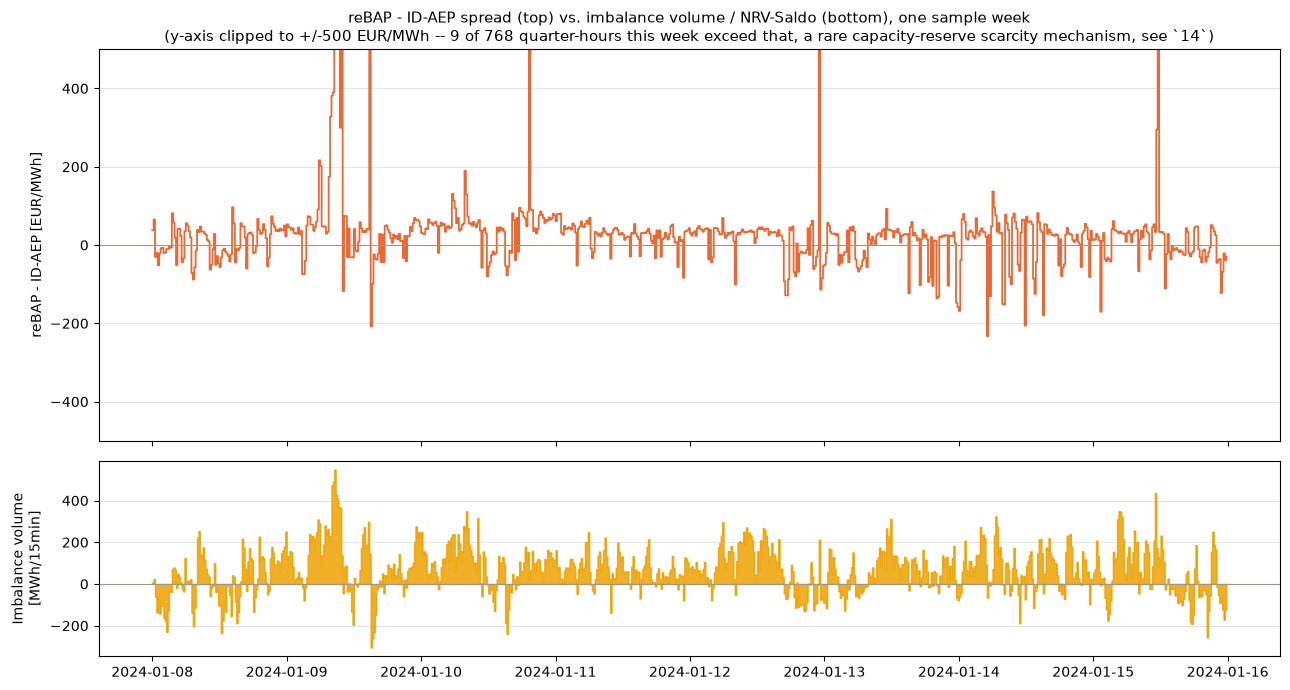

In [6]:
sample = panel.loc["2024-01-08":"2024-01-15"].copy()
sample["imbalance_volume_mwh"] = sample["nrv_saldo"] * 0.25
n_clipped = (sample["spread_id"].abs() > 500).sum()

fig, (ax_spread, ax_vol) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, height_ratios=[2, 1])

ax_spread.step(sample.index, sample["spread_id"], where="post", color=REBAP_COLOR, linewidth=1.3)
ax_spread.axhline(0, color=NEUTRAL, linewidth=0.8)
ax_spread.set_ylim(-500, 500)
ax_spread.set_ylabel("reBAP - ID-AEP [EUR/MWh]")
ax_spread.set_title(
    f"reBAP - ID-AEP spread (top) vs. imbalance volume / NRV-Saldo (bottom), one sample week\n"
    f"(y-axis clipped to +/-500 EUR/MWh -- {n_clipped} of {len(sample)} quarter-hours this week exceed that, "
    f"a rare capacity-reserve scarcity mechanism, see `14`)",
    fontsize=10.5,
)
ax_spread.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax_spread.set_axisbelow(True)

ax_vol.fill_between(sample.index, sample["imbalance_volume_mwh"], 0, color=NRV_COLOR, alpha=0.85, step="post")
ax_vol.axhline(0, color=NEUTRAL, linewidth=0.8)
ax_vol.set_ylabel("Imbalance volume\n[MWh/15min]")
ax_vol.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax_vol.set_axisbelow(True)
fig.tight_layout()
plt.show()

Every swing in the bottom panel has a same-direction counterpart
directly above it -- the time-series view of the 100% same-sign result
found above, not just an aggregate statistic.

## Takeaways

- **The intuition -- "shouldn't reBAP vs. intraday be a tighter imbalance
  signal than reBAP vs. day-ahead?" -- is right, but the improvement
  shows up in *direction*, not in *magnitude*.** Same-sign agreement
  rises from ~93% to a clean 100%; Pearson r barely changes.
- **Both effects trace back to reBAP's own published calculation
  formula** (`14`), not an empirical pattern found by chance: Module 2 is
  built as `ID-AEP +/- a distance` with the sign chosen by the balance's
  own sign -- exactly the mechanism for the 100% same-sign result -- while
  the large-magnitude tail is governed by Module 1 (merit-order) and
  Module 3 (a scarcity parabola), neither linear in the balance at all.
- ID-AEP's own history (2020-07-01 onward) is shorter than reBAP/
  NRV-Saldo's (2014-01-01) -- not a limitation for this question, but it
  does mean this page's window is shorter than `07`'s or `09`'s.